In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


files = {
    'Apple': 'Apple dataset.csv',
    'Arhar': 'Arhar dataset.csv',
    'Potato': 'potato dataset.csv',
    'Onion': 'onion dataset.csv',
    'Wheat': 'Wheat dataset.csv'
}


dfs = []
for comm, file in files.items():
    df = pd.read_csv(file)  # or pd.read_excel if .xlsx
    df['Commodity'] = comm
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)

full_df.columns = full_df.columns.str.strip().str.lower()

full_df['t'] = pd.to_datetime(full_df['t'], errors='coerce', dayfirst=True)

full_df = full_df.sort_values(['commodity', 't']).reset_index(drop=True)

print(full_df.head())
print(full_df.info())  # Check dtypes, missing values
print(full_df['commodity'].value_counts())
print(full_df.groupby('commodity')['t'].agg(['min', 'max']))
full_df = full_df[['t', 'commodity', 'state_name', 'market_name', 'variety', 'p_modal', 'p_min', 'p_max']]
full_df.to_csv('merged_agri_prices.csv', index=False)

C:\Users\vinee\AppData\Local\Temp\ipykernel_19280\2325558251.py:25: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  full_df['t'] = pd.to_datetime(full_df['t'], errors='coerce', dayfirst=True)


           t  cmdty  market_id   market_name  state_id state_name  \
0 2022-01-02  Apple        399  Gaddiannaram        36  Telangana   
1 2022-01-03  Apple        399  Gaddiannaram        36  Telangana   
2 2022-01-05  Apple        399  Gaddiannaram        36  Telangana   
3 2022-01-07  Apple        399  Gaddiannaram        36  Telangana   
4 2022-01-10  Apple        399  Gaddiannaram        36  Telangana   

   district_id district_name variety  p_min   p_max  p_modal commodity  
0          536     Hyderabad   Simla   2222  5000.0     3056     Apple  
1          536     Hyderabad   Simla   1667  8000.0     2778     Apple  
2          536     Hyderabad   Simla   2778  5556.0     3889     Apple  
3          536     Hyderabad   Simla   3333  5000.0     3889     Apple  
4          536     Hyderabad   Simla   1667  3889.0     2222     Apple  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35751 entries, 0 to 35750
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dt

In [2]:
#data preprocessing- droping the rows containg null values
#feature enginerring-created new features
full_df = full_df.dropna(subset=['t', 'p_modal'])
full_df = full_df[full_df['p_modal'] > 0]
full_df = full_df.sort_values(['commodity', 't'])
full_df.set_index('t', inplace=True)
full_df['year'] = full_df.index.year
full_df['month'] = full_df.index.month
full_df['day'] = full_df.index.day
full_df['dayofweek'] = full_df.index.dayofweek
full_df['quarter'] = full_df.index.quarter
for lag in [1, 7, 30, 90]:
    full_df[f'lag_{lag}'] = full_df.groupby('commodity')['p_modal'].shift(lag)
for window in [7, 30, 90]:
    full_df[f'rolling_mean_{window}'] = full_df.groupby('commodity')['p_modal'].transform(lambda x: x.shift(1).rolling(window).mean())
    full_df[f'rolling_std_{window}']  = full_df.groupby('commodity')['p_modal'].transform(lambda x: x.shift(1).rolling(window).std())
full_df = full_df.dropna()
print("Shape after feature engineering:", full_df.shape)
print(full_df.groupby('commodity').size())
full_df.to_csv('agri_prices_features.csv', index=True)
print("Final columns:", full_df.columns.tolist())

Shape after feature engineering: (35291, 22)
commodity
Apple      1650
Arhar     10323
Onion     10434
Potato    12582
Wheat       302
dtype: int64
Final columns: ['commodity', 'state_name', 'market_name', 'variety', 'p_modal', 'p_min', 'p_max', 'year', 'month', 'day', 'dayofweek', 'quarter', 'lag_1', 'lag_7', 'lag_30', 'lag_90', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30', 'rolling_mean_90', 'rolling_std_90']


In [43]:
!pip install xgboost

In [44]:
full_df

,commodity,state_name,market_name,variety,p_modal,p_min,p_max,year,month,day,...,lag_1,lag_7,lag_30,lag_90,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,rolling_mean_90,rolling_std_90
t,,,,,,,,,,,,,,,,,,,,,
2022-04-12,Apple,Telangana,Gaddiannaram,Simla,8889,5556,12778.0,2022,4,12,...,4444.0,8333.0,3889.0,3056.0,5674.428571,2301.271305,4786.833333,2156.236410,4185.077778,1502.402220
2022-04-13,Apple,Telangana,Gaddiannaram,Simla,4444,2778,8333.0,2022,4,13,...,8889.0,3889.0,3333.0,2778.0,5753.714286,2238.202159,4823.866667,2139.884524,4203.588889,1495.116544
2022-04-14,Apple,Telangana,Gaddiannaram,Simla,8889,5556,12778.0,2022,4,14,...,4444.0,4444.0,3333.0,3889.0,6388.714286,2427.254396,5009.066667,2244.285631,4259.144444,1574.104251
2022-04-15,Apple,Telangana,Gaddiannaram,Simla,5000,2778,8333.0,2022,4,15,...,8889.0,9167.0,3333.0,3889.0,5793.428571,2124.401238,5064.633333,2221.881580,4271.488889,1575.524591
2022-04-16,Apple,Telangana,Gaddiannaram,Simla,8611,6111,13333.0,2022,4,16,...,5000.0,4444.0,3333.0,2222.0,6388.714286,2262.582574,5240.566667,2288.016468,4342.477778,1625.292100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-19,Wheat,Telangana,Zaheerabad,147 Average,2450,2450,2550.0,2025,9,19,...,2454.0,2350.0,2453.0,2468.0,2347.000000,271.753565,2338.800000,243.817823,2320.755556,321.200848
2025-09-22,Wheat,Telangana,Zaheerabad,147 Average,2656,2656,2656.0,2025,9,22,...,2450.0,1852.0,2400.0,2350.0,2461.857143,183.126030,2347.333333,250.423962,2324.155556,323.127655
2025-09-23,Wheat,Telangana,Zaheerabad,147 Average,2364,2364,2364.0,2025,9,23,...,2656.0,2376.0,2310.0,2211.0,2460.142857,184.117199,2349.133333,250.340421,2325.855556,322.928056


MAE:  57.27 ₹/quintal
RMSE: 95.15 ₹/quintal
MAPE: 2.62%


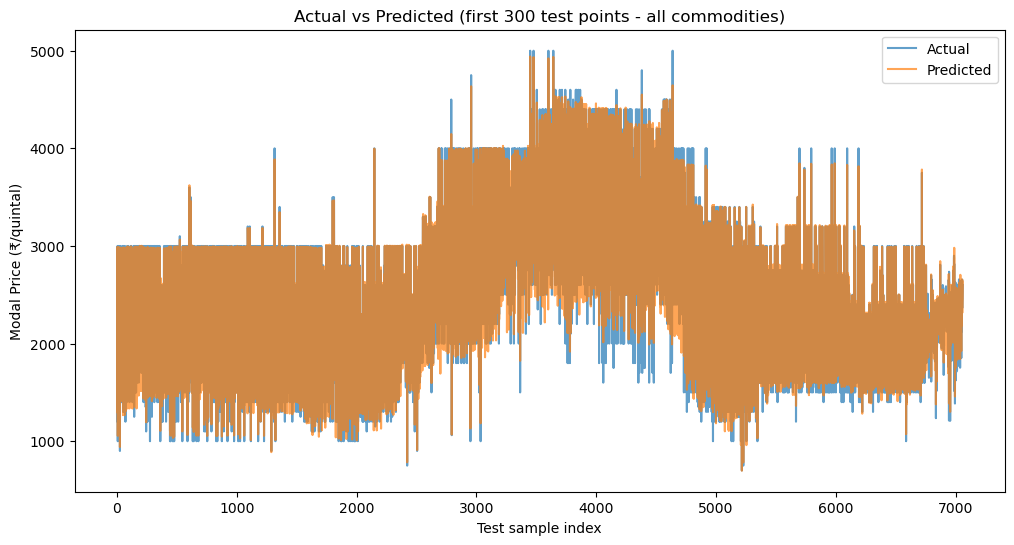


Feature Importances:
p_max                0.547415
commodity_encoded    0.155350
rolling_mean_30      0.123616
rolling_mean_90      0.079807
p_min                0.058215
market_id            0.008945
rolling_mean_7       0.007277
rolling_std_30       0.004506
rolling_std_7        0.002820
rolling_std_90       0.002700
month                0.001708
lag_1                0.001502
year                 0.001404
quarter              0.001002
lag_90               0.000871
lag_7                0.000833
lag_30               0.000742
day                  0.000645
dayofweek            0.000641
dtype: float32


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.tree import DecisionTreeRegressor

le = LabelEncoder()
le_2 = LabelEncoder()
full_df['commodity_encoded'] = le.fit_transform(full_df['commodity'])
full_df['market_id'] = le_2.fit_transform(full_df['market_name'])

features = [
    'commodity_encoded', 'year', 'month', 'day', 'dayofweek', 'quarter',
    'lag_1', 'lag_7', 'lag_30', 'lag_90',
    'rolling_mean_7', 'rolling_mean_30', 'rolling_mean_90',
    'rolling_std_7', 'rolling_std_30', 'rolling_std_90','p_min','p_max','market_id'
]

target = 'p_modal'

X = full_df[features]
y = full_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(
    np.abs((y_test-y_pred)/np.maximum(y_test,1))
)*100

print(f"MAE:  {mae:.2f} ₹/quintal")
print(f"RMSE: {rmse:.2f} ₹/quintal")
print(f"MAPE: {mape:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted (first 300 test points - all commodities)')
plt.xlabel('Test sample index')
plt.ylabel('Modal Price (₹/quintal)')
plt.legend()
plt.show()

importances = model.feature_importances_
feature_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(feature_imp)

In [4]:
import joblib
joblib.dump(model, "price_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "commodity_encoder.pkl")

['commodity_encoder.pkl']

In [5]:
full_df['market_id'].unique().max()

np.int64(73)

In [6]:
joblib.dump(le_2,'Label_encoder_2.pkl')

['Label_encoder_2.pkl']

In [7]:
import pickle

# Load the saved label encoder
with open("Label_encoder_2.pkl", "rb") as f:
    classes = pickle.load(f)

In [8]:
com = "Alampur"

if com in classes:
    encoded_value = np.where(classes == com)[0][0]
else:
    encoded_value = -1

print("Encoded value:", encoded_value)

Encoded value: 2


In [51]:
import math

In [52]:
ddf = full_df[full_df['commodity']=='Apple']
mini = math.inf
market = 'None'
for i in ddf['p_modal']:
    if(i<mini):
        mini = i

In [53]:
mini

2000

In [54]:
ddf[ddf['market_name']=='Gudimalkapur']

,commodity,state_name,market_name,variety,p_modal,p_min,p_max,year,month,day,...,lag_30,lag_90,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,rolling_mean_90,rolling_std_90,commodity_encoded,market_id
t,,,,,,,,,,,,,,,,,,,,,


In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
param_grid = {
    'n_estimators' : [100,150,250,300],
    'eta': [0.01,0.04,0.05],
    'max_depth' : [3,4,5,6],
    'gamma' : [0.1,0.2]
}

In [57]:
grid_search = GridSearchCV(estimator=model,param_grid=param_grid,cv=3)

In [58]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=0.05, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=6, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'eta': [0.01, 0.04, 0.05], 'gamma': [0.1, 0.2],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [100, 150, 250, 300]})

In [59]:
grid_search.best_params_

{'eta': 0.01, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 300}

In [60]:
y_pred2 = grid_search.predict(X_test)

MAE:  49.94 ₹/quintal
RMSE: 79.92 ₹/quintal
MAPE: 2.29%


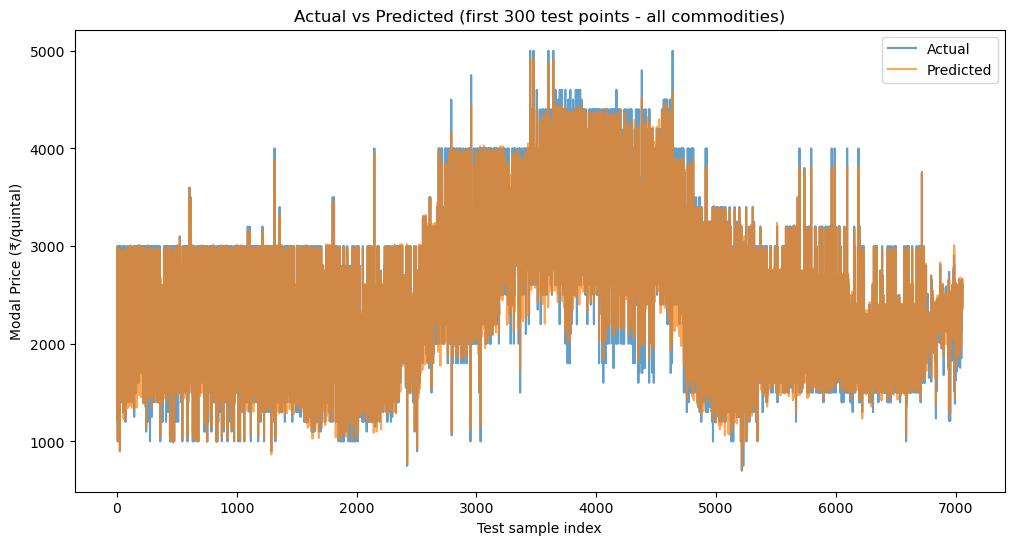

In [61]:
mae = mean_absolute_error(y_test, y_pred2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
mape = np.mean(np.abs((y_test - y_pred2) / y_test)) * 100

print(f"MAE:  {mae:.2f} ₹/quintal")
print(f"RMSE: {rmse:.2f} ₹/quintal")
print(f"MAPE: {mape:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred2, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted (first 300 test points - all commodities)')
plt.xlabel('Test sample index')
plt.ylabel('Modal Price (₹/quintal)')
plt.legend()
plt.show()